# SSD MobileNet V2 (320×320) — PhenoBench QAT (qat3)

Quantization-aware training (**scheme: `full`, + head** — full int8 (backbone + head)) for
**single-class plant instance detection**, resuming from the companion *finetune* notebook's
`ptq/` export and publishing a self-contained `qat3/` artifact.

This is one of four sibling QAT notebooks (`qat0`…`qat3`) for this config; each
runs a different scheme over the *same* finetuned starting point, so they are
independent and individually re-runnable.

## Inputs

- **Finetune output** — attach this config's finetune notebook output via
  *Add Input → Your Work / Notebook Output*. Kaggle mounts it at
  `/kaggle/input/notebooks/freimutdiener/ssd-mn2-sc-phenobench-320-finetune`; its `ptq/` (zoo layout: `checkpoint/` +
  `pipeline.config`) is the QAT `model_path`.
- The PhenoBench dataset bundle (`train.record` / `val.record` / `label_map`).

## Output contract (`/kaggle/working`)

On completion the working directory holds exactly:

```
/kaggle/working/
├── manifest.qat3.json    # fragment manifest: only the `qat3` stage
└── qat3/
    ├── checkpoint/          # fake-quantized model-only ckpt-0
    ├── saved_model/         # SavedModel (fp32-simulated quant graph)
    ├── graphs/              # training / validation curves (PDF)
    ├── pipeline.config      # as-run TFOD pipeline
    ├── best_metric.json
    └── metrics_history.json
```

The fragment is merged into the finetune's `manifest.json` after the fact
(`ExperimentManifest.merge`), keeping each `qatN` run decoupled.

## 1 · Environment

Target runtime (Kaggle, "Pin to original environment" enabled):

- Python 3.10 · TensorFlow 2.11 · CUDA-enabled GPU

In [1]:
!python -V

Python 3.10.10


In [2]:
!pip install --no-cache-dir --no-deps \
  tf_slim \
  pycocotools \
  lvis \
  contextlib2 \
  gin-config \
  tf-models-official==2.13.2 \
  tensorflow-model-optimization==0.7.5 \
  git+https://github.com/frdiener/agri-vision-edge.git@qat-resume-head

  Cloning https://github.com/frdiener/agri-vision-edge.git (to revision qat-resume-head) to /tmp/pip-req-build-29cv6a7k
  Running command git clone --filter=blob:none --quiet https://github.com/frdiener/agri-vision-edge.git /tmp/pip-req-build-29cv6a7k
  Running command git checkout -b qat-resume-head --track origin/qat-resume-head
  Switched to a new branch 'qat-resume-head'
  Branch 'qat-resume-head' set up to track remote branch 'qat-resume-head' from 'origin'.
  Resolved https://github.com/frdiener/agri-vision-edge.git to commit bda9f72b308a6a8e8e0023967ae9f3433d4e8b1f
  Installing build dependencies ... - \ | / done
  Getting requirements to build wheel ... - done
  Preparing metadata (pyproject.toml) ... - done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 352.1/352.1 kB 13.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 472.5/472.5 kB 52.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.3/61.3 kB 319.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━

In [3]:
import json
import shutil
from pathlib import Path
from dataclasses import asdict
import matplotlib.pyplot as plt

# setup_tensorflow_models() must run before anything imports object_detection.
from agri_vision_edge.third_party import setup_tensorflow_models
setup_tensorflow_models()

from agri_vision_edge.experiment import (
    ExperimentManifest,
    capture_environment,
)
from agri_vision_edge.experiment import (
    AugmentationConfig,
    FineTuneConfig,
)

# The shared trainer: one config object drives finetune / QAT + export.
from agri_vision_edge.tfod_trainer import (
    FinetuneRunConfig,
    run_finetune,
    write_pipeline,
    export_run,
)

# Curves are read back from the trainer's metrics_history.json (no TensorBoard).
from agri_vision_edge.evaluation.curves import (
    load_history_scalars,
    available_tags,
    plot_metric_curves,
    plot_loss_curves,
    plot_learning_rate,
    plot_steps_per_second,
    plot_map_curves,
    plot_recall_curves,
)

/opt/conda/lib/python3.10/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.23.5
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


## 2 · Output paths

`tfod_trainer` writes its working tree into a `/tmp` scratch dir; the published
`/kaggle/working` holds only the `manifest.qat3.json` fragment and the
assembled `qat3/` artifact.

In [4]:
WORK = Path("/kaggle/working")

QAT_DIR = WORK / "qat3"
GRAPHS_PATH = QAT_DIR / "graphs"
MANIFEST_PATH = WORK / "manifest.qat3.json"

# Finetune export consumed as the QAT starting point (model_path).
FINETUNE_DIR = Path("/kaggle/input/notebooks/freimutdiener/ssd-mn2-sc-phenobench-320-finetune")
PTQ_DIR = FINETUNE_DIR / "ptq"

# Intermediate scratch (kept off /kaggle/working so it is never published).
RUN_DIR = Path("/tmp/ave_qat3_run")

GRAPHS_PATH.mkdir(parents=True, exist_ok=True)
assert PTQ_DIR.exists(), (
    f"Finetune export not found at {PTQ_DIR} -- attach this config's "
    "finetune notebook output as an input."
)

## 3 · Experiment manifest (fragment)

A **fragment** manifest carrying only this QAT stage. It is merged into the
finetune's full `manifest.json` later (`ExperimentManifest.merge`, which merges
disjoint stages + artifacts and raises on a duplicate). The QAT run's
environment is recorded inside the stage `runtime` so it survives the merge.

In [5]:
manifest = ExperimentManifest(
    name="ssd-mobilenet-v2_sc_phenobench_320x320",
    task="object_detection",
)

env = capture_environment()
manifest.set_environment(platform="kaggle", **env)

## 4 · QAT configuration

The pipeline tuning (anchors, matcher thresholds, base augmentation, NMS) is
**inherited from the finetune's manifest** (`stages.finetune.config`) so the
anchor semantics the head was trained against are preserved exactly. Only the
QAT-specific knobs are overridden:

- **Optimization** softened — QAT resumes from converged fp32 weights, so a low
  learning rate and a short schedule suffice for the weights to adapt to the
  fake-quantization nodes.
- **Augmentation** softened — photometric jitter and random crop/zoom dropped,
  keeping only the geometric (flip / 90° rotation) symmetries.
- **Scheme:** `full` + detection head — full int8 (backbone + head)

In [6]:
# Inherit the finetune's pipeline tuning (anchors, matcher thresholds, base
# augmentation, NMS) from its manifest, so the anchor semantics the head was
# trained against are preserved exactly. Only the QAT knobs are overridden.
finetune_config = dict(
    ExperimentManifest.load(FINETUNE_DIR / "manifest.json")
    .data["stages"]["finetune"]["config"]
)

# Soften augmentation for QAT: drop photometric jitter and random crop/zoom,
# keep the geometric (flip / 90-degree rotation) symmetries.
augmentation = AugmentationConfig(**finetune_config.pop("augmentation"))
augmentation.random_crop = False
augmentation.zoom_range = None
augmentation.brightness_max_delta = None
augmentation.contrast_range = None
augmentation.saturation_range = None
augmentation.jpeg_quality_range = None

config = FineTuneConfig(**finetune_config, augmentation=augmentation)

# QAT optimization schedule -- low LR, short run from converged fp32 weights.
config.learning_rate_base = 0.0002
config.warmup_learning_rate = 2e-05
config.num_steps = 4000
config.warmup_steps = 100

manifest.add_stage(
    "qat3",
    config={
        **asdict(config),
        "qat_scheme": "full",
        "quantize_head": True,
    },
    runtime={"environment": env},
)

"defined"

'defined'

## 5 · Dataset

A `tfod_trainer` *dataset bundle* is a directory holding `label_map.pbtxt`,
`train.record` and `val.record` — exactly the layout of the mounted
`sc-phenobench` dataset. The raw PhenoBench images are used only for
qualitative evaluation at the end.

In [7]:
manifest.set_dataset(
    name="phenobench",
    train_split="train",
    validation_split="val",
    num_classes=1,
)

dataset_dir = Path("/kaggle/input/datasets/freimutdiener/sc-phenobench")
dataset_raw_dir = Path("/kaggle/input/datasets/freimutdiener/phenobench-raw-dataset-v1-1-0/PhenoBench")

label_map_path = dataset_dir / "label_map.pbtxt"
test_imgs = list((dataset_raw_dir / "test" / "images").glob("*.png"))

print(f"{len(test_imgs)} test images loaded")

693 test images loaded


## 6 · Starting point and run configuration

The QAT `model_path` is the finetune's `ptq/` export — a drop-in zoo-layout
base model (`checkpoint/ckpt-0.*` + `pipeline.config`). `run_finetune` folds the
BatchNorms and inserts the fake-quant nodes (`qat_scheme="full"`, `quantize_head=True`) on top of the
restored weights.

In [8]:
manifest.set_checkpoint(
    model_name="ssd_mobilenet_v2_320x320_coco17_tpu-8",
    pretrained_dataset="phenobench (finetune)",
    source="finetune_ptq_export",
)

# The finetune export, in TF model-zoo layout, is the QAT base model.
MODEL_DIR = PTQ_DIR

In [9]:
run_config = FinetuneRunConfig(
    model_path=MODEL_DIR,
    dataset_bundle_path=dataset_dir,
    num_classes=1,
    output_dir=RUN_DIR,      # scratch; the published artifact is assembled into QAT_DIR
    finetune=config,
    #
    # Quantization-aware training.
    #
    qat_scheme="full",
    quantize_head=True,
    # fold_bn / reset_optimizer default to True whenever a qat_scheme is set.
)

# Render the as-run pipeline now so it can be inspected before training.
write_pipeline(run_config)

print("Pipeline:", run_config.pipeline_config_path)

Pipeline: /tmp/ave_qat3_run/finetune/pipeline.config


## 7 · Training

`run_finetune` builds the detection model, restores the COCO checkpoint, and
runs the training loop with metric-based checkpointing and early stopping,
appending one record per logged step to `metrics_history.json` and saving the
best checkpoint (by validation mAP) under the scratch run directory.

In [10]:
result = run_finetune(run_config)

Loading fine-tune checkpoint (full): /kaggle/input/notebooks/freimutdiener/ssd-mn2-sc-phenobench-320-finetune/ptq/checkpoint/ckpt-0


/opt/conda/lib/python3.10/site-packages/keras/backend.py:451: UserWarning: `tf.keras.backend.set_learning_phase` is deprecated and will be removed after 2020-10-11. To update it, simply pass a True/False value to the `training` argument of the `__call__` method of your layer or model.
  warnings.warn(


Resetting the optimizer...
Folding batchnorms into the convolutions...
Adding fake quantization nodes to the backbone (scheme=full)...
Quantizing the detection head (feature maps + box predictor, scheme=full)...

Evaluating initial modified configuration...
creating index...
index created!
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=3.51s).
Accumulating evaluation results...
DONE (t=0.33s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.000
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets

In [11]:
# Promote the metric files from the scratch run dir into the qat3 artifact.
shutil.copy2(result.best_metric_path, QAT_DIR / "best_metric.json")
shutil.copy2(result.history_path, QAT_DIR / "metrics_history.json")

best = json.loads((QAT_DIR / "best_metric.json").read_text())
print(
    f"Best {best['metric_name']}: {best['metric_value']:.5f} "
    f"at step {best['step']}"
)

manifest.update_stage("qat3", metrics={"best_metric": best})
manifest.update_stage(
    "qat3",
    artifacts={
        "best_metric_json": "qat3/best_metric.json",
        "metrics_history_json": "qat3/metrics_history.json",
    },
)

Best DetectionBoxes_Precision/mAP: 0.20532 at step 700


## 8 · Training and validation curves

QAT curves read back from `qat3/metrics_history.json`; each figure is saved
into `qat3/graphs/` as a vector PDF.

In [12]:
history_df = load_history_scalars(QAT_DIR / "metrics_history.json")

print("Available metric tags:")
for tag in available_tags(history_df):
    print("-", tag)

Available metric tags:
- DetectionBoxes_Precision/mAP
- DetectionBoxes_Precision/mAP (large)
- DetectionBoxes_Precision/mAP (medium)
- DetectionBoxes_Precision/mAP (small)
- DetectionBoxes_Precision/mAP@.50IOU
- DetectionBoxes_Precision/mAP@.75IOU
- DetectionBoxes_Recall/AR@1
- DetectionBoxes_Recall/AR@10
- DetectionBoxes_Recall/AR@100
- DetectionBoxes_Recall/AR@100 (large)
- DetectionBoxes_Recall/AR@100 (medium)
- DetectionBoxes_Recall/AR@100 (small)
- Loss/classification_loss
- Loss/localization_loss
- Loss/regularization_loss
- Loss/total_loss
- learning_rate
- steps_per_sec


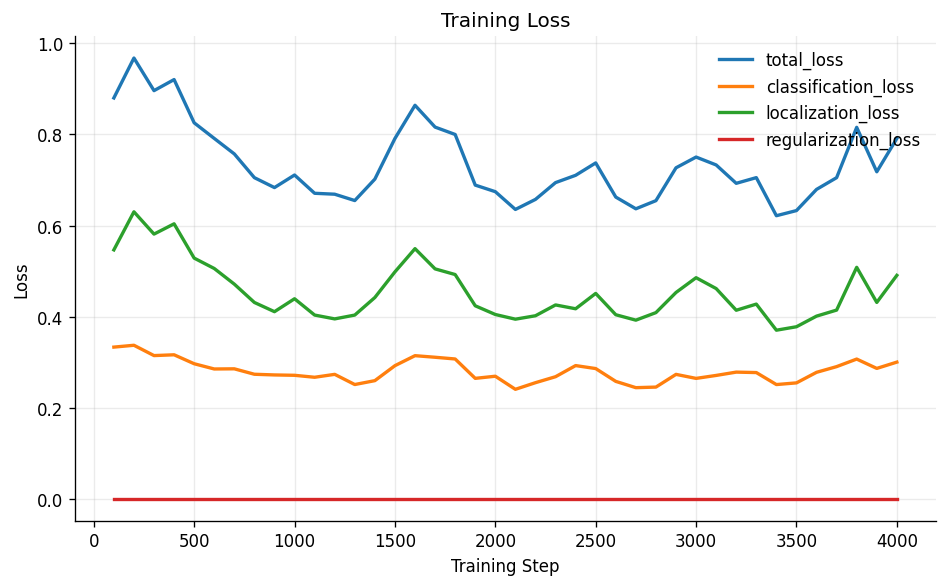

In [13]:
loss_fig, _ = plot_loss_curves(
    history_df, smoothing=0.6,
    save_path=GRAPHS_PATH / "training_loss_curves.pdf",
)
display(loss_fig)

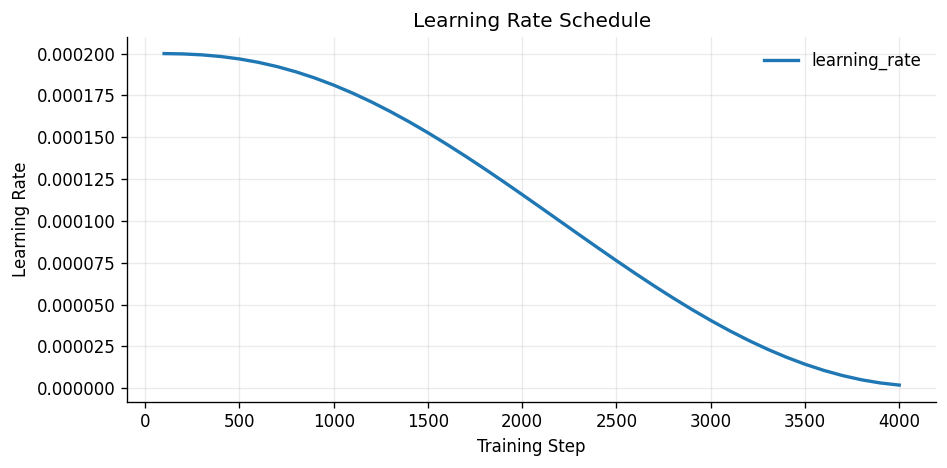

In [14]:
lr_fig, _ = plot_learning_rate(
    history_df, smoothing=0.6,
    save_path=GRAPHS_PATH / "learning_rate_schedule.pdf",
)
display(lr_fig)

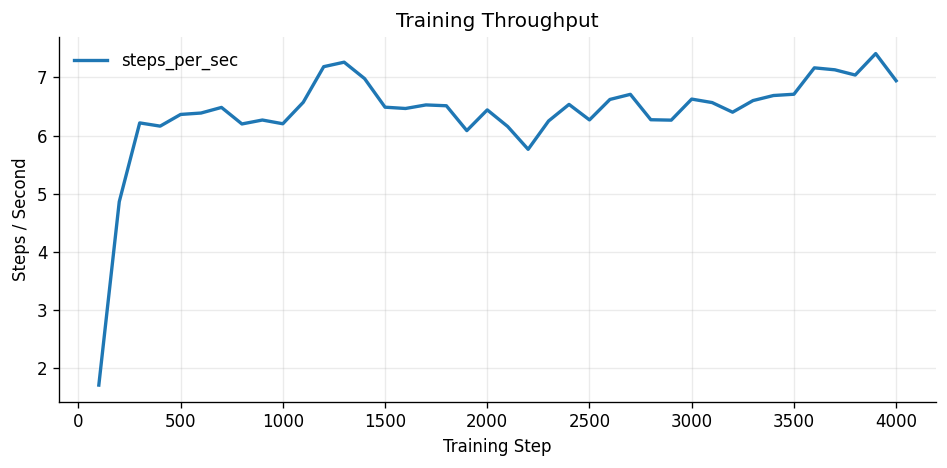

In [15]:
tput_fig, _ = plot_steps_per_second(
    history_df, smoothing=0.5,
    save_path=GRAPHS_PATH / "training_throughput.pdf",
)
display(tput_fig)

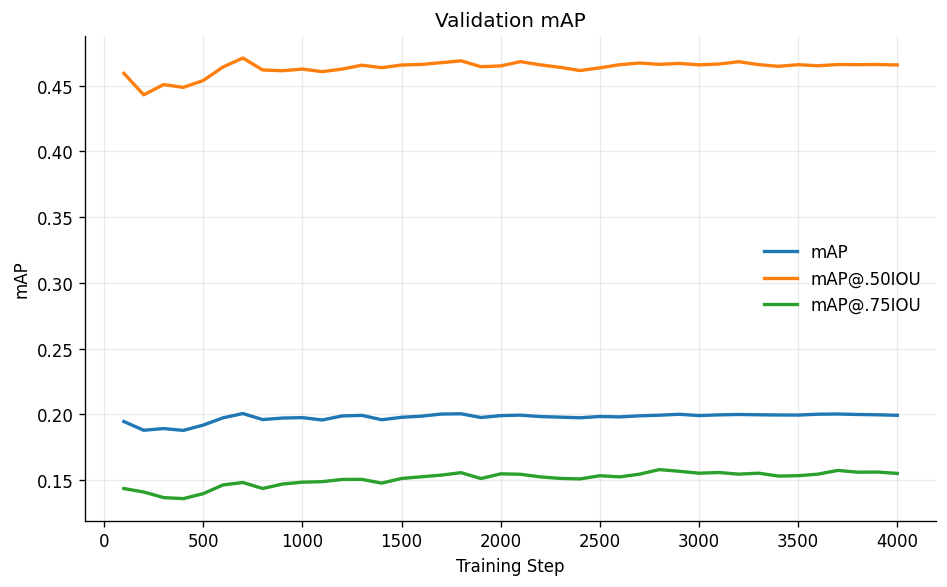

In [16]:
map_fig, _ = plot_map_curves(
    history_df, smoothing=0.6,
    save_path=GRAPHS_PATH / "eval_precision_curves.pdf",
)
display(map_fig)

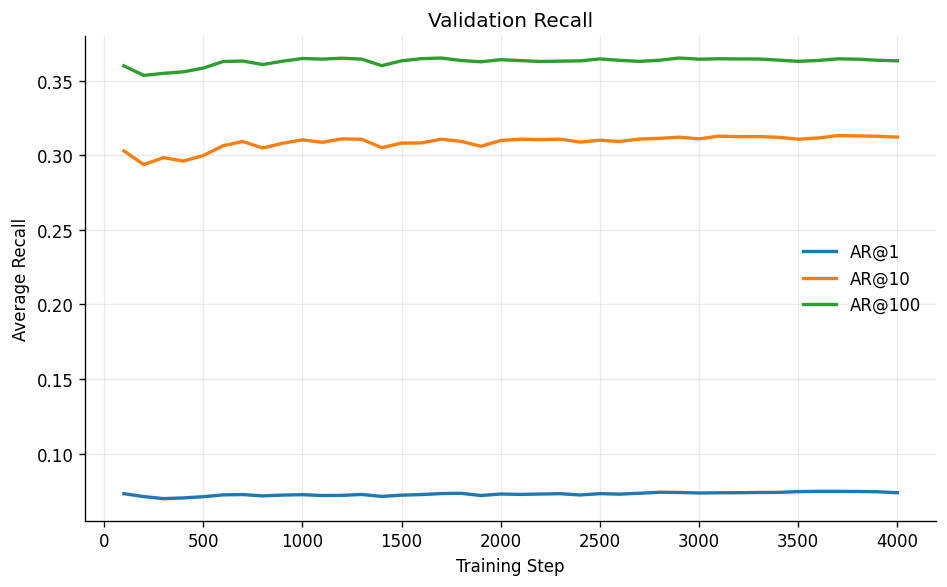

In [17]:
recall_fig, _ = plot_recall_curves(
    history_df, smoothing=0.6,
    save_path=GRAPHS_PATH / "eval_recall_curves.pdf",
)
display(recall_fig)

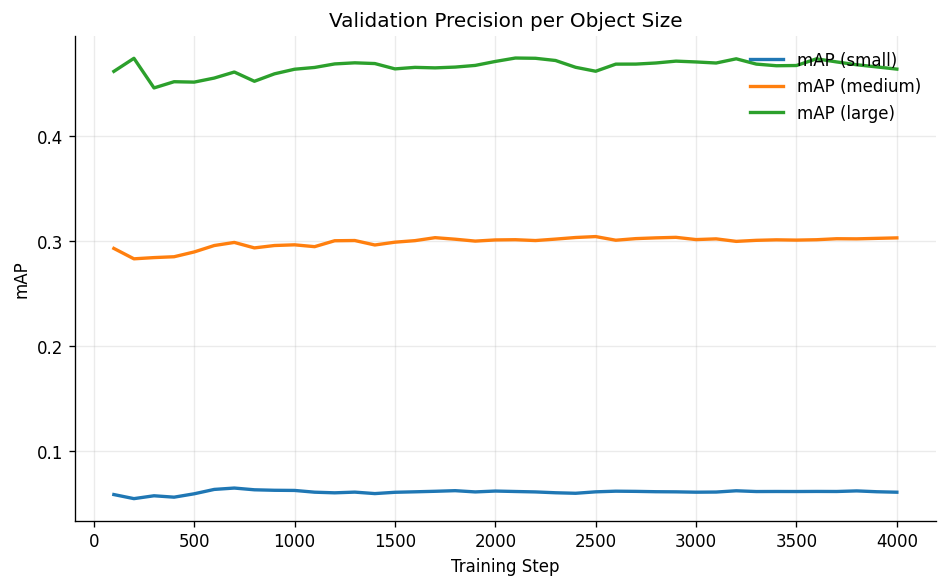

In [18]:
size_precision_fig, _ = plot_metric_curves(
    df=history_df,
    tags=[
        "DetectionBoxes_Precision/mAP (small)",
        "DetectionBoxes_Precision/mAP (medium)",
        "DetectionBoxes_Precision/mAP (large)",
    ],
    title="Validation Precision per Object Size",
    ylabel="mAP",
    smoothing=0.6,
    save_path=GRAPHS_PATH / "eval_precision_size_curves.pdf",
)
display(size_precision_fig)

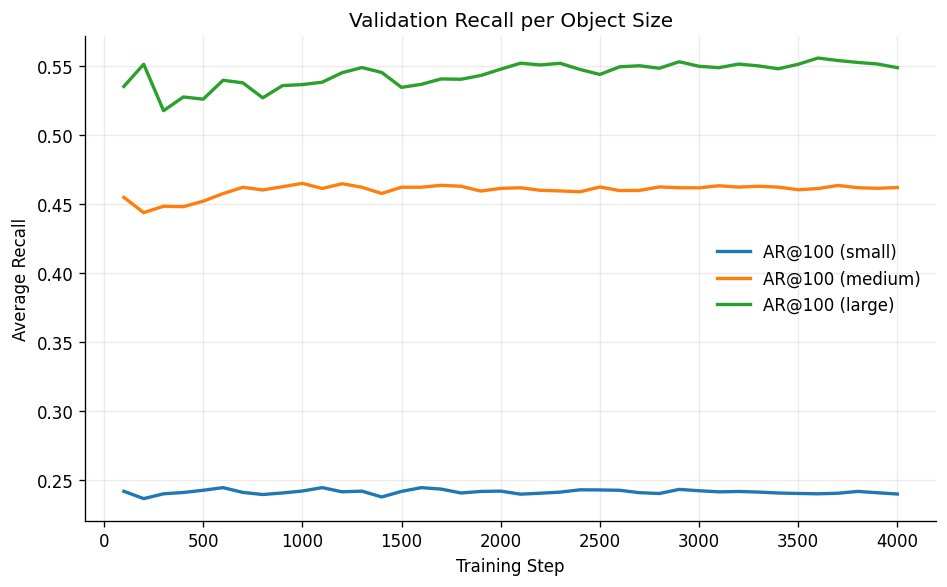

In [19]:
size_recall_fig, _ = plot_metric_curves(
    df=history_df,
    tags=[
        "DetectionBoxes_Recall/AR@100 (small)",
        "DetectionBoxes_Recall/AR@100 (medium)",
        "DetectionBoxes_Recall/AR@100 (large)",
    ],
    title="Validation Recall per Object Size",
    ylabel="Average Recall",
    smoothing=0.6,
    save_path=GRAPHS_PATH / "eval_recall_size_curves.pdf",
)
display(size_recall_fig)

## 9 · Export

`export_run` reproduces the trained graph (fold + `quantize_backbone` + `quantize_detection_head`) and
writes the best checkpoint to the zoo layout directly into `qat3/`. The
defaults pick up `cfg.qat_scheme`/`cfg.quantize_head`, so the exported variable
structure matches the QAT checkpoint.

In [20]:
export_result = export_run(run_config, export_dir=QAT_DIR)

print("qat3 dir: ", export_result.export_dir)
print("SavedModel:", export_result.saved_model_dir)
print("Checkpoint:", export_result.checkpoint)
print("Pipeline:  ", export_result.pipeline_config)

Folding batchnorms into the convolutions...
Adding fake quantization nodes to the backbone (scheme=full)...
Quantizing the detection head (feature maps + box predictor, scheme=full)...
qat3 dir:  /kaggle/working/qat3
SavedModel: /kaggle/working/qat3/saved_model
Checkpoint: /kaggle/working/qat3/checkpoint/ckpt-0
Pipeline:   /kaggle/working/qat3/pipeline.config


## 10 · Register artifacts and publish

In [21]:
manifest.add_artifact("qat3/pipeline.config", artifact_type="pipeline_config", stage="qat3")
manifest.add_artifact("qat3/graphs", artifact_type="evaluation_plots", stage="qat3")
manifest.add_artifact("qat3/saved_model", artifact_type="tfod_saved_model", stage="qat3")
manifest.add_artifact("qat3/checkpoint", artifact_type="tfod_checkpoint", stage="qat3")

manifest.save(MANIFEST_PATH)

# Drop the scratch run dir so /kaggle/working == {manifest.qat3.json, qat3/}.
shutil.rmtree(RUN_DIR, ignore_errors=True)

print("Published:")
for p in sorted(WORK.rglob("*")):
    if p.is_file():
        print(" ", p.relative_to(WORK))

Published:
  __notebook__.ipynb
  manifest.qat3.json
  qat3/best_metric.json
  qat3/checkpoint/checkpoint
  qat3/checkpoint/ckpt-0.data-00000-of-00001
  qat3/checkpoint/ckpt-0.index
  qat3/graphs/eval_precision_curves.pdf
  qat3/graphs/eval_precision_size_curves.pdf
  qat3/graphs/eval_recall_curves.pdf
  qat3/graphs/eval_recall_size_curves.pdf
  qat3/graphs/learning_rate_schedule.pdf
  qat3/graphs/training_loss_curves.pdf
  qat3/graphs/training_throughput.pdf
  qat3/metrics_history.json
  qat3/pipeline.config
  qat3/saved_model/fingerprint.pb
  qat3/saved_model/saved_model.pb
  qat3/saved_model/variables/variables.data-00000-of-00001
  qat3/saved_model/variables/variables.index


## 11 · Qualitative evaluation

Predictions on unseen PhenoBench test images, using the exported SavedModel from
`qat3/` (fake-quant graph, evaluated in fp32 simulation).

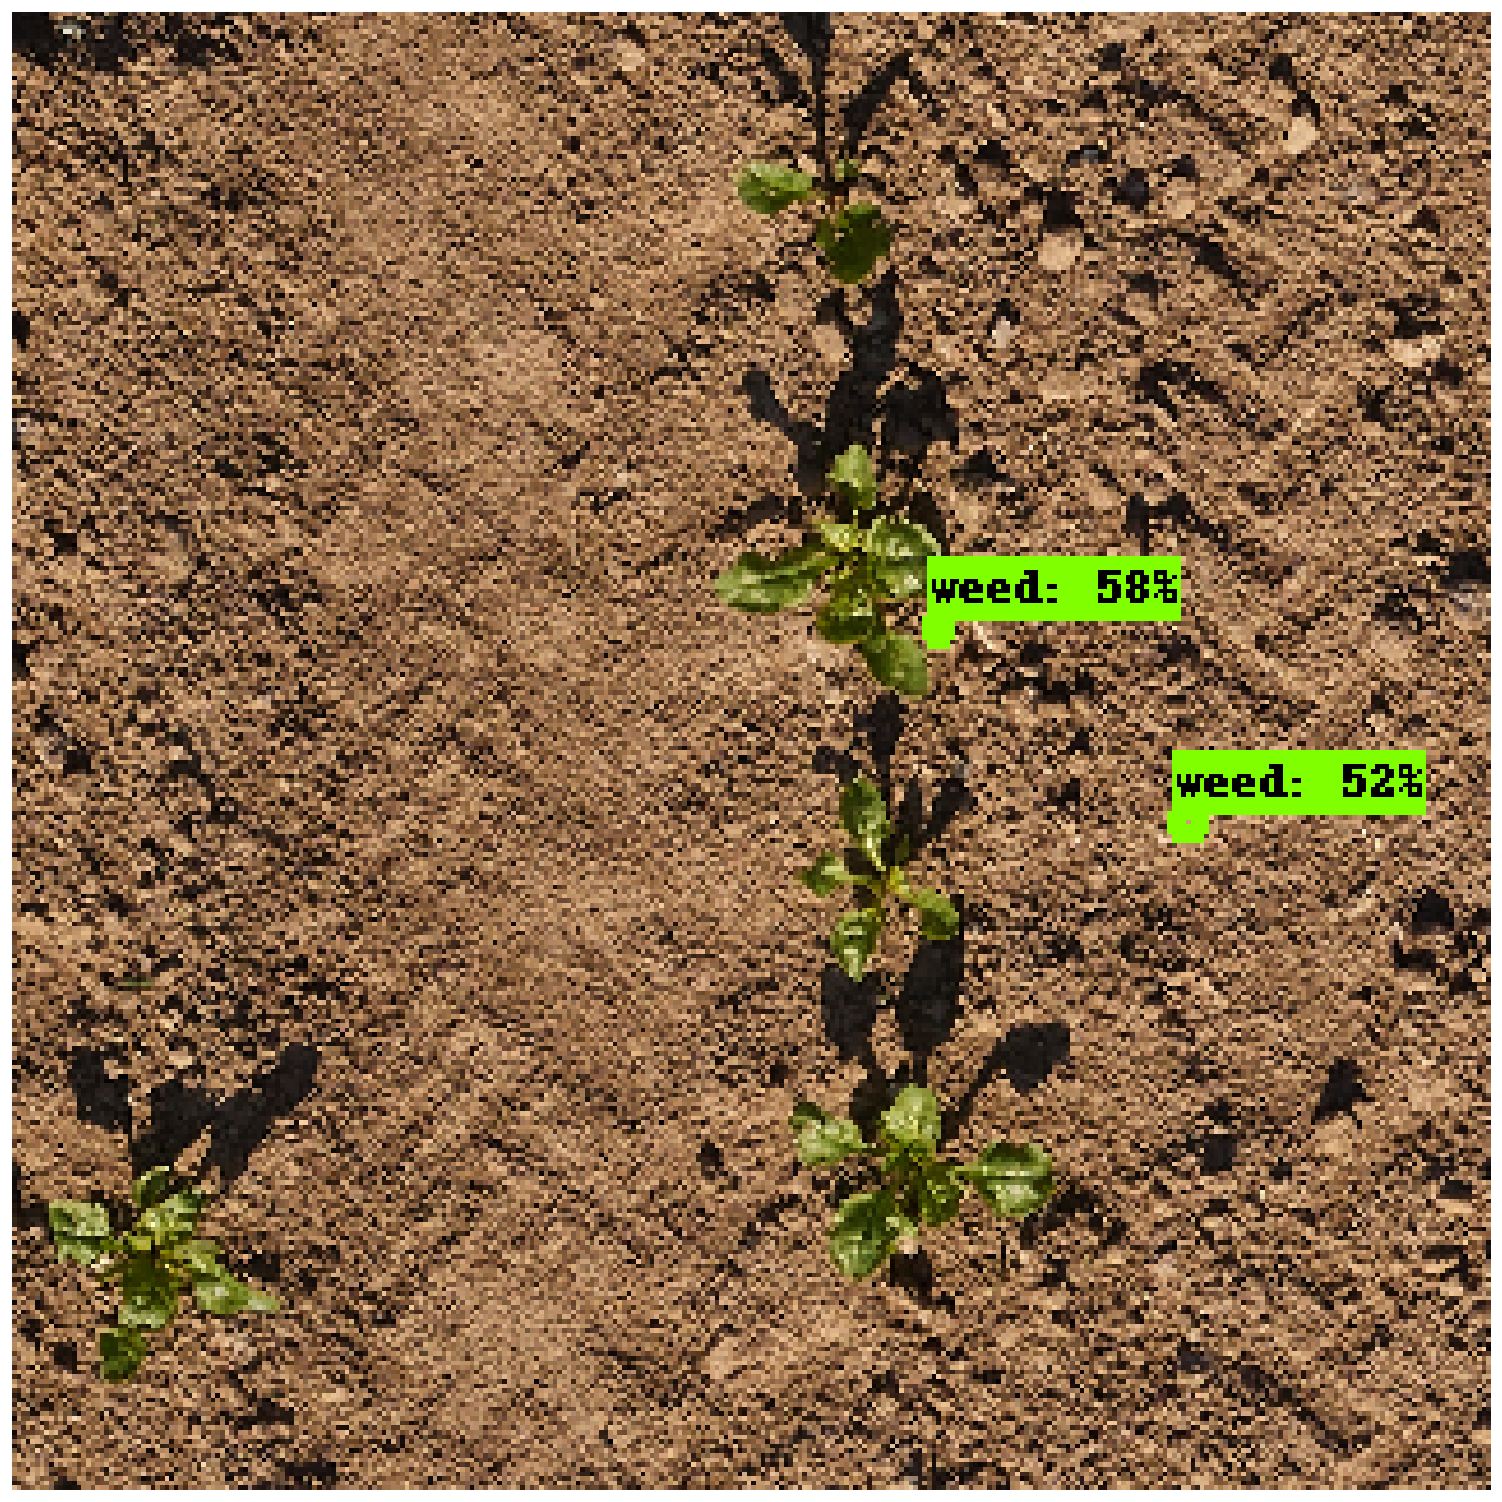

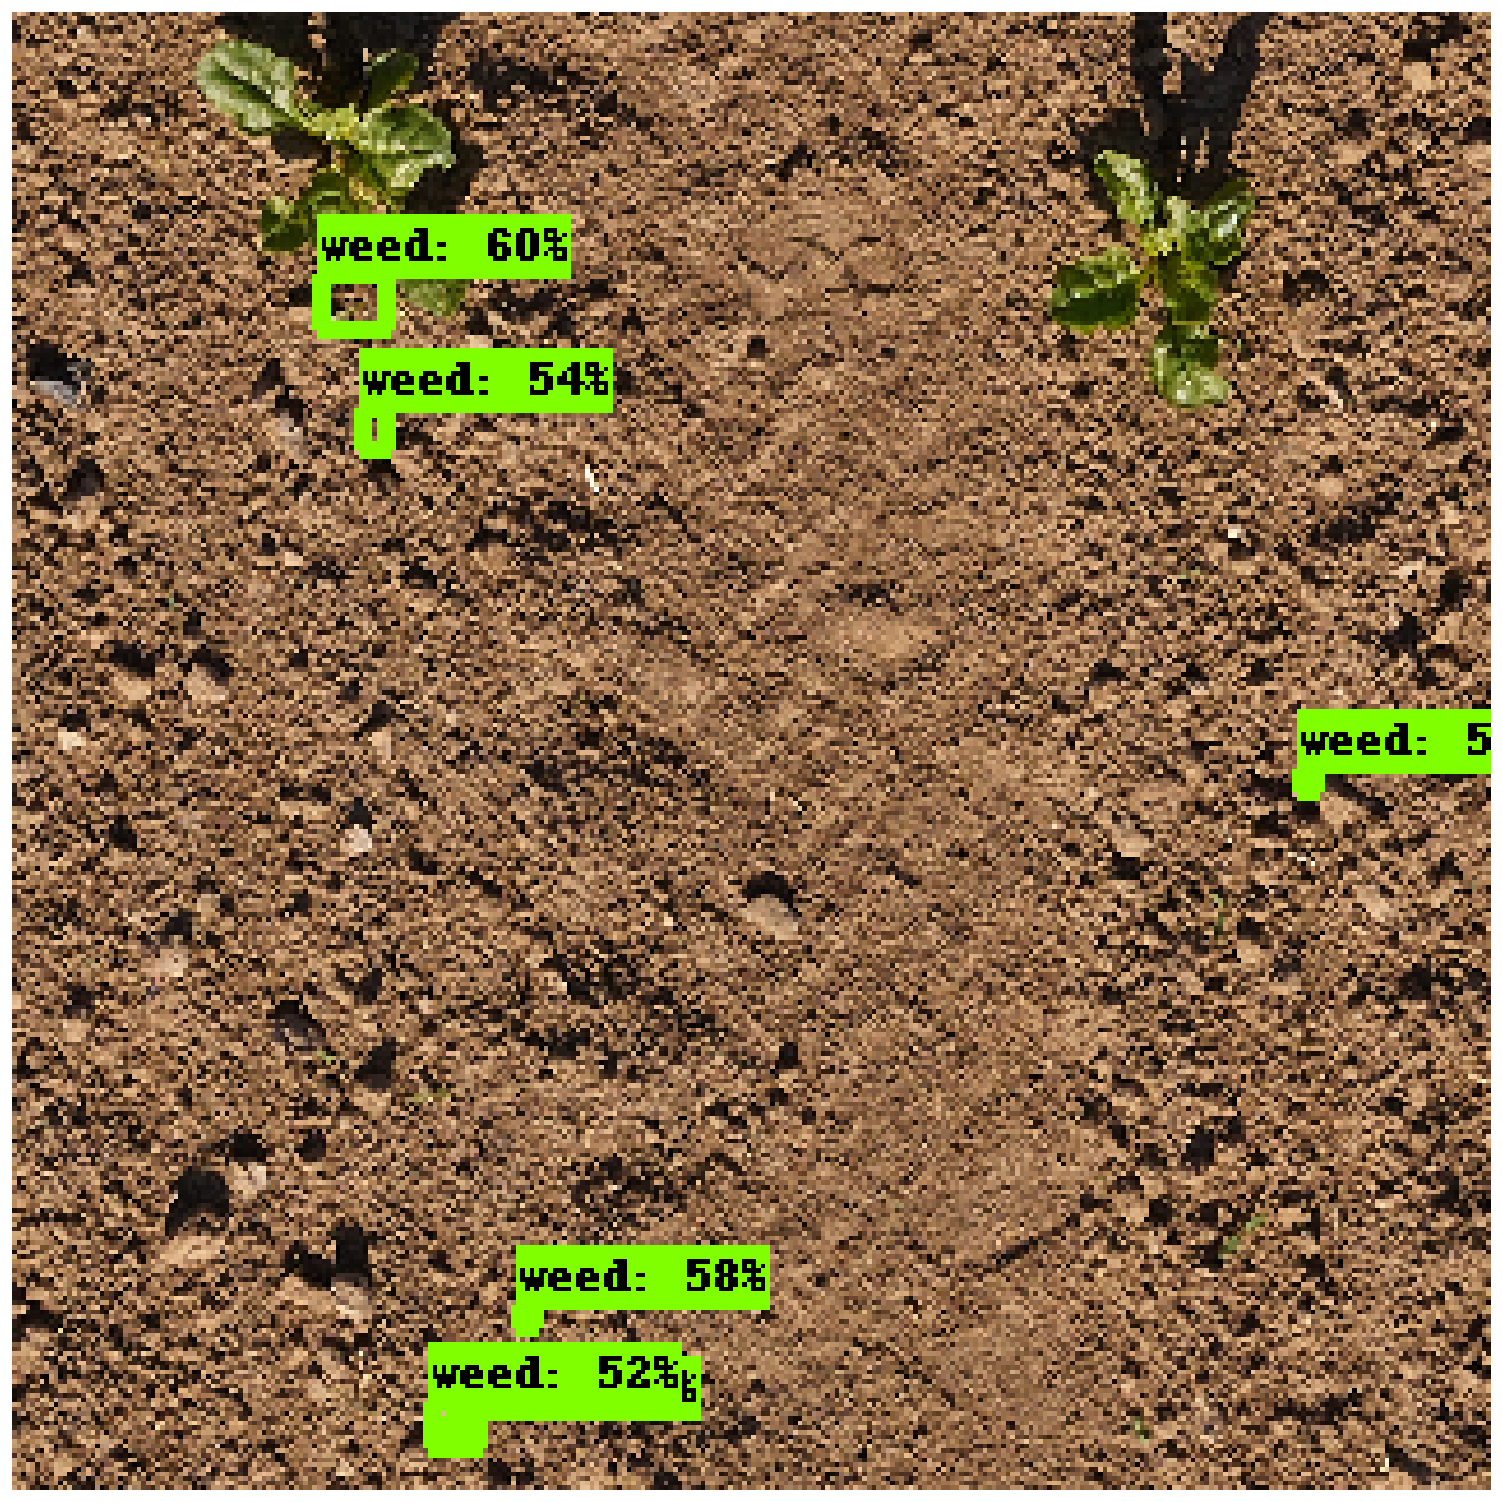

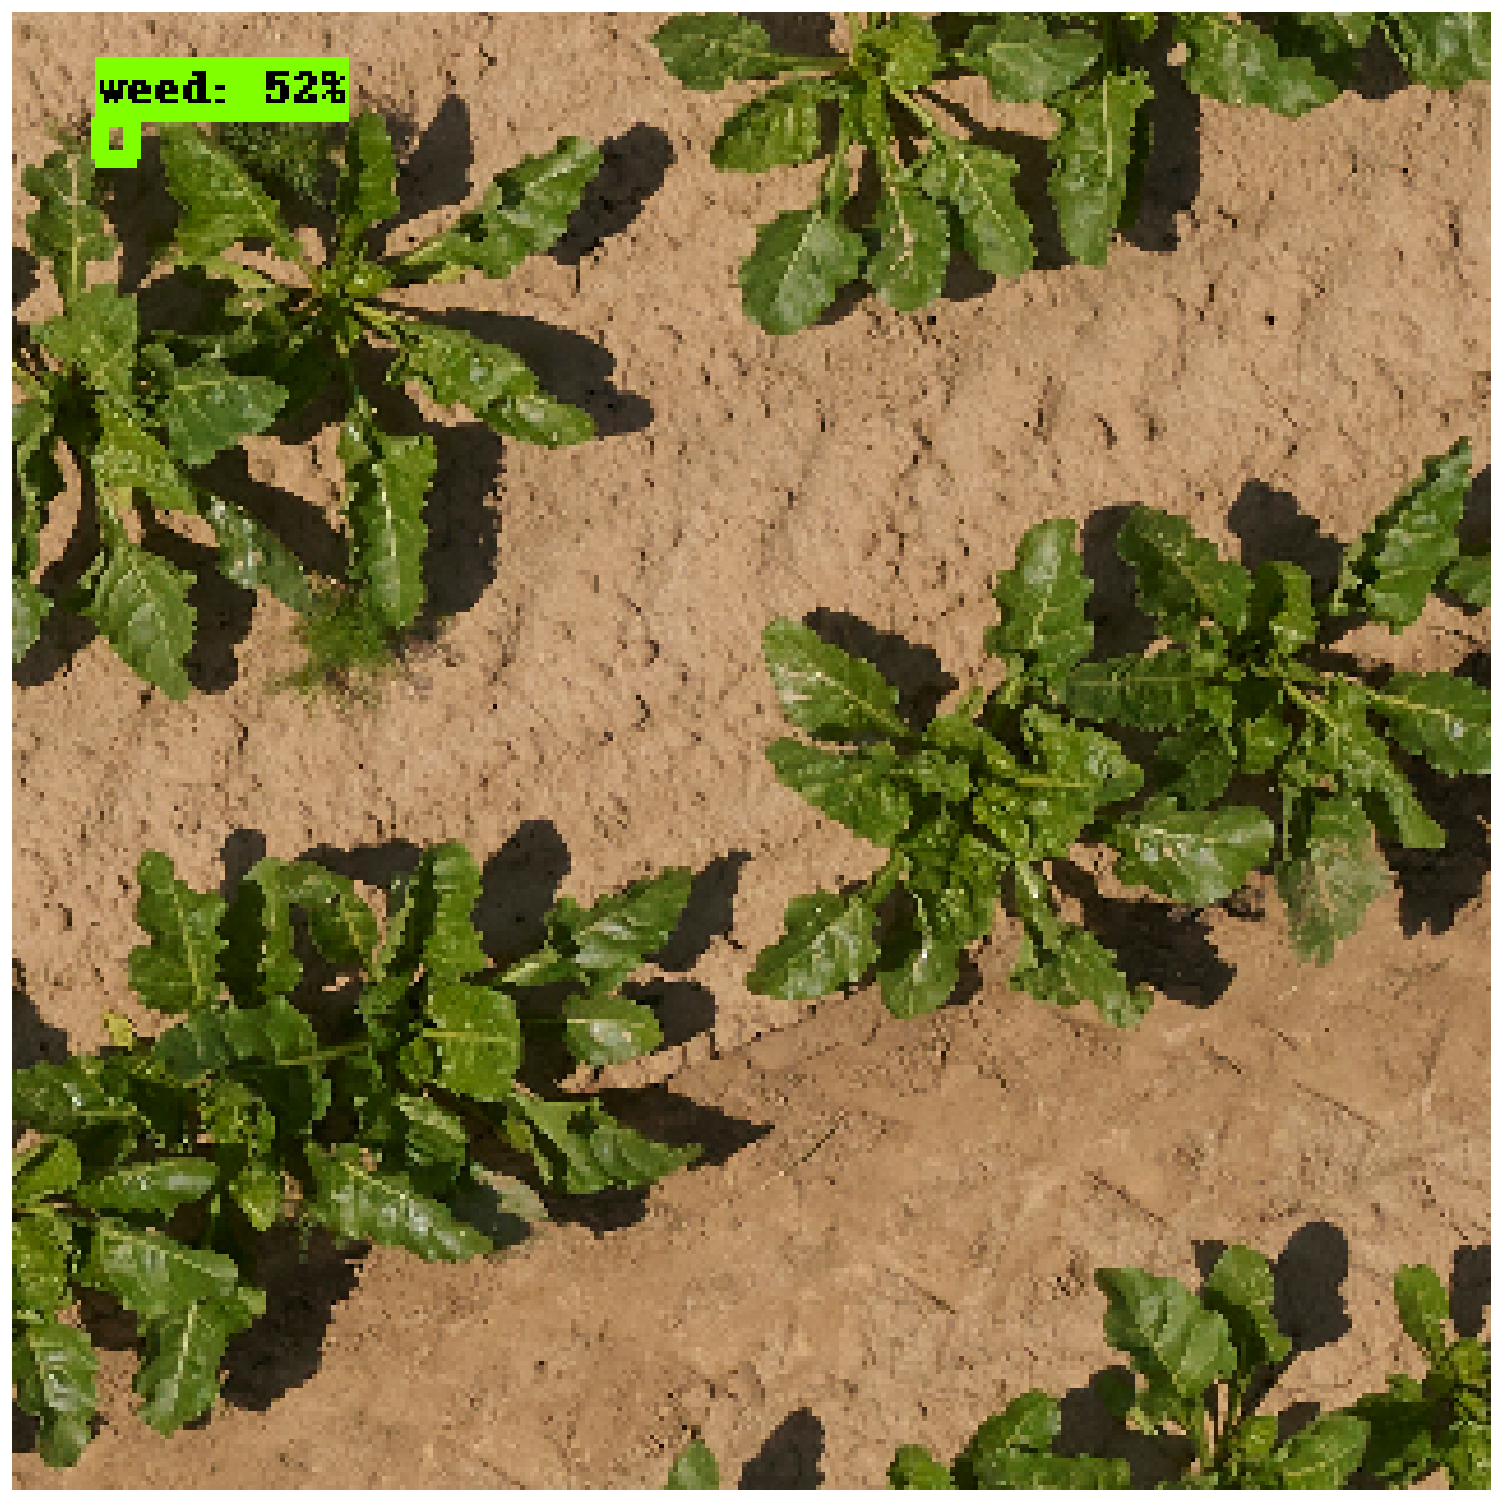

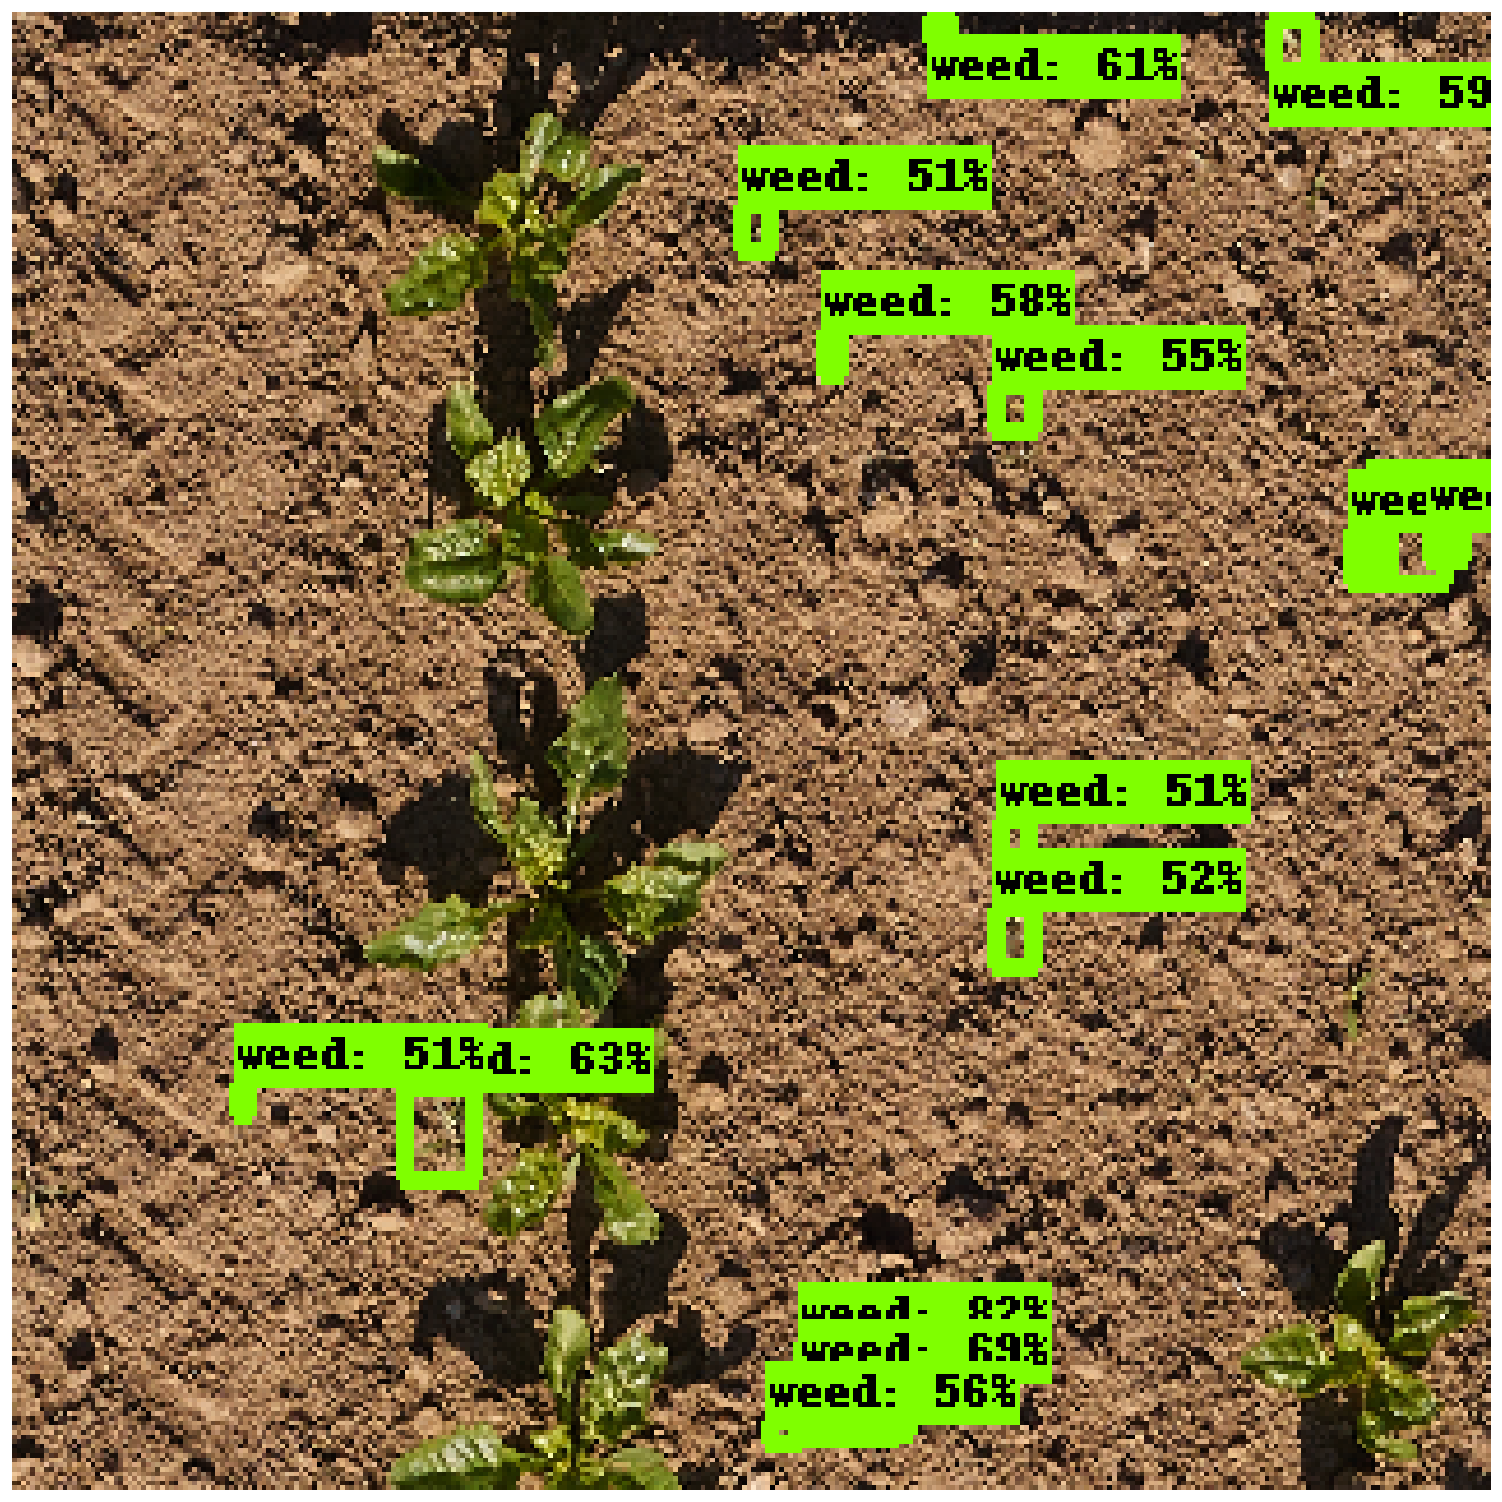

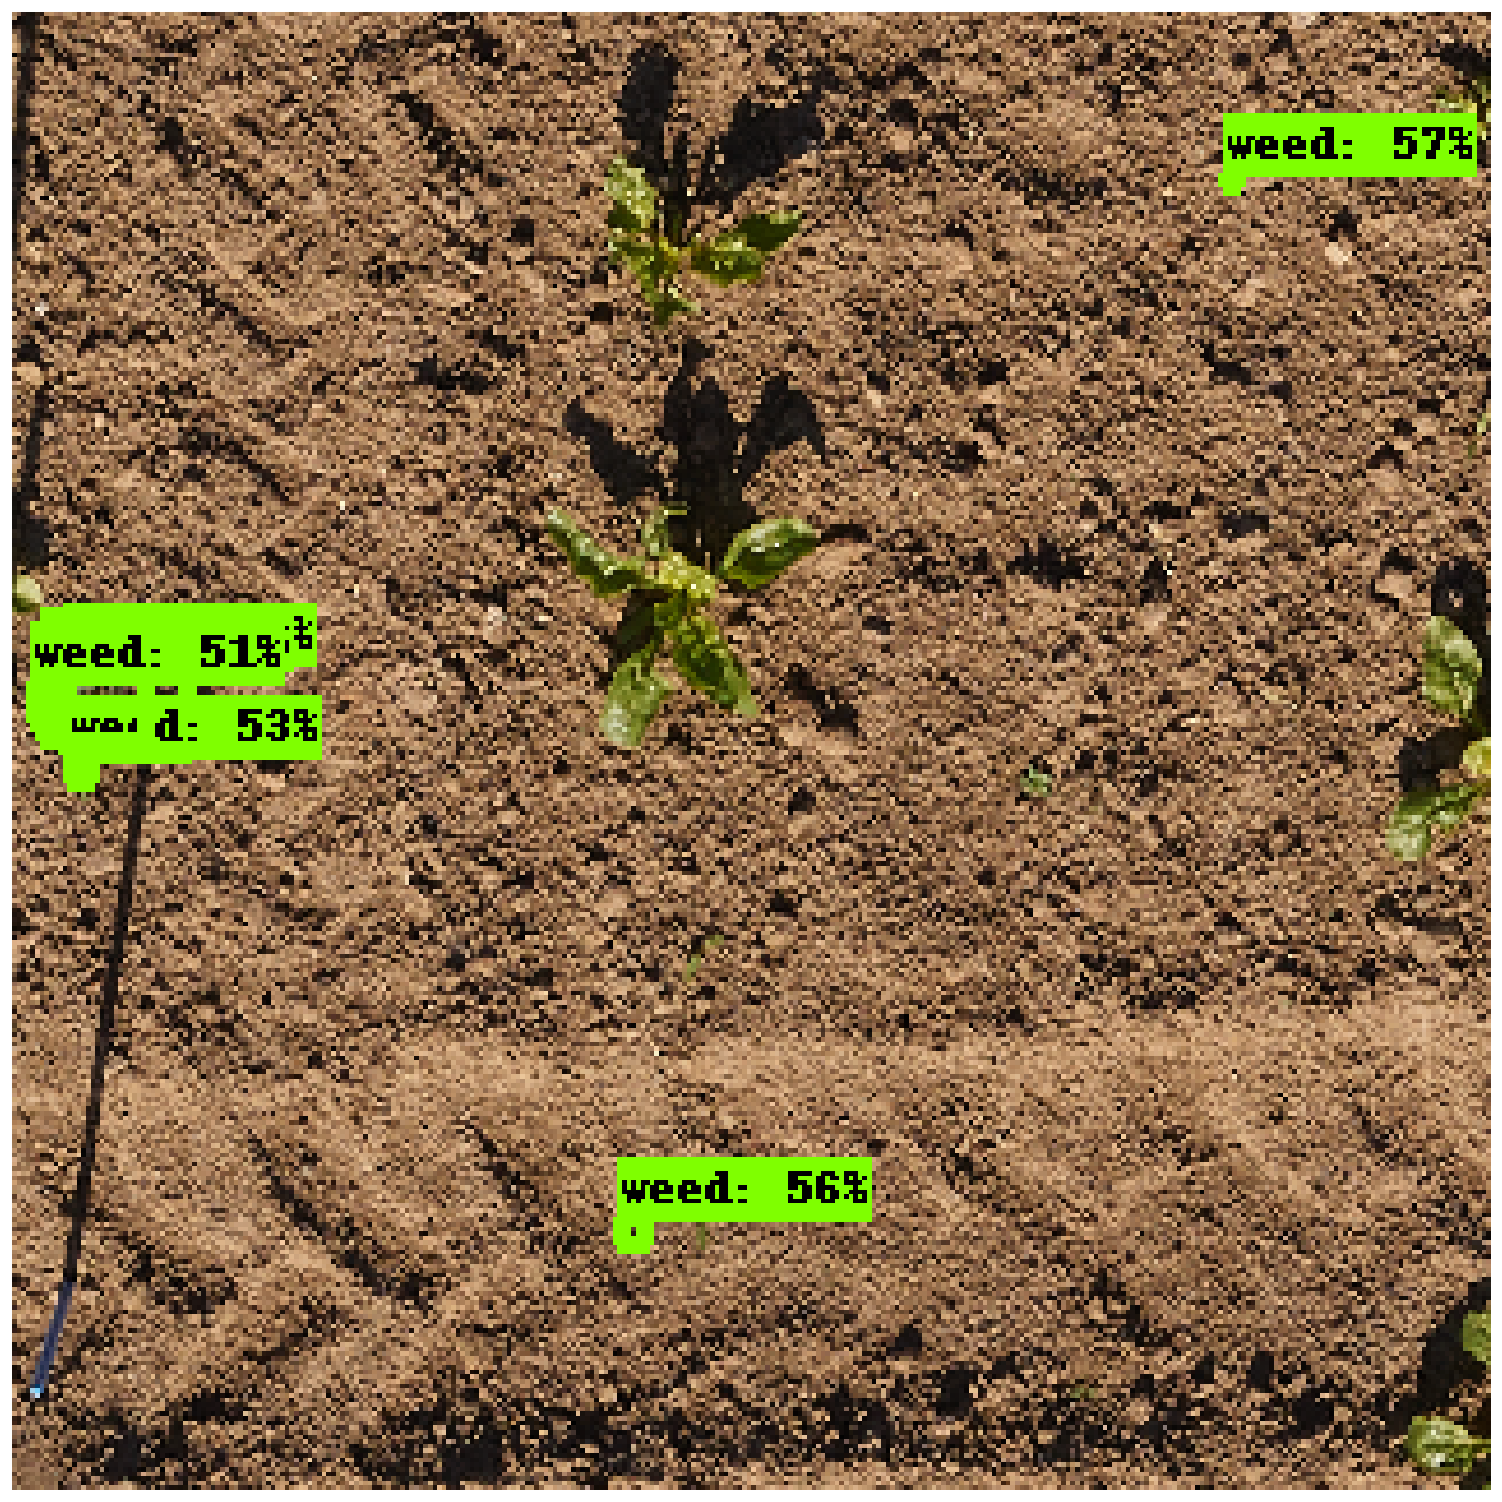

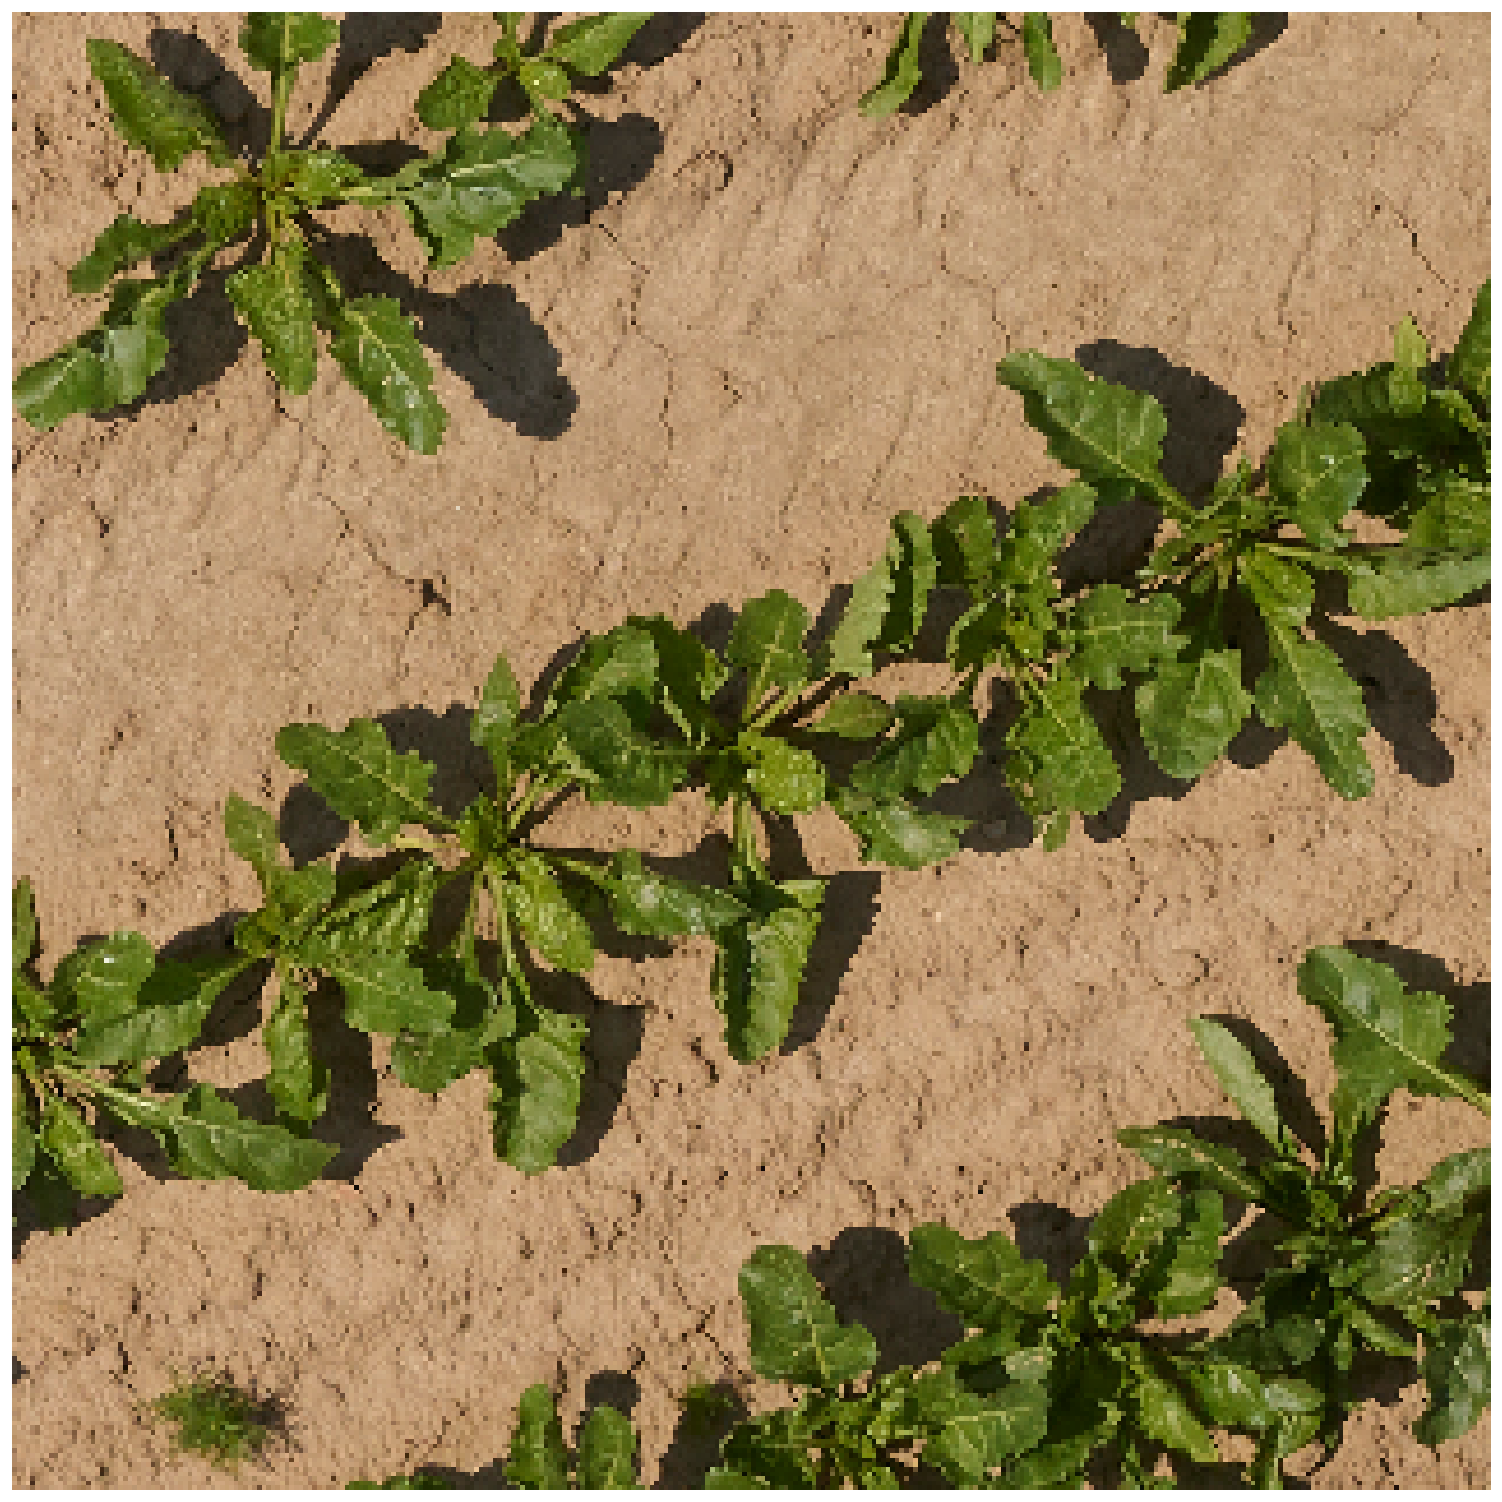

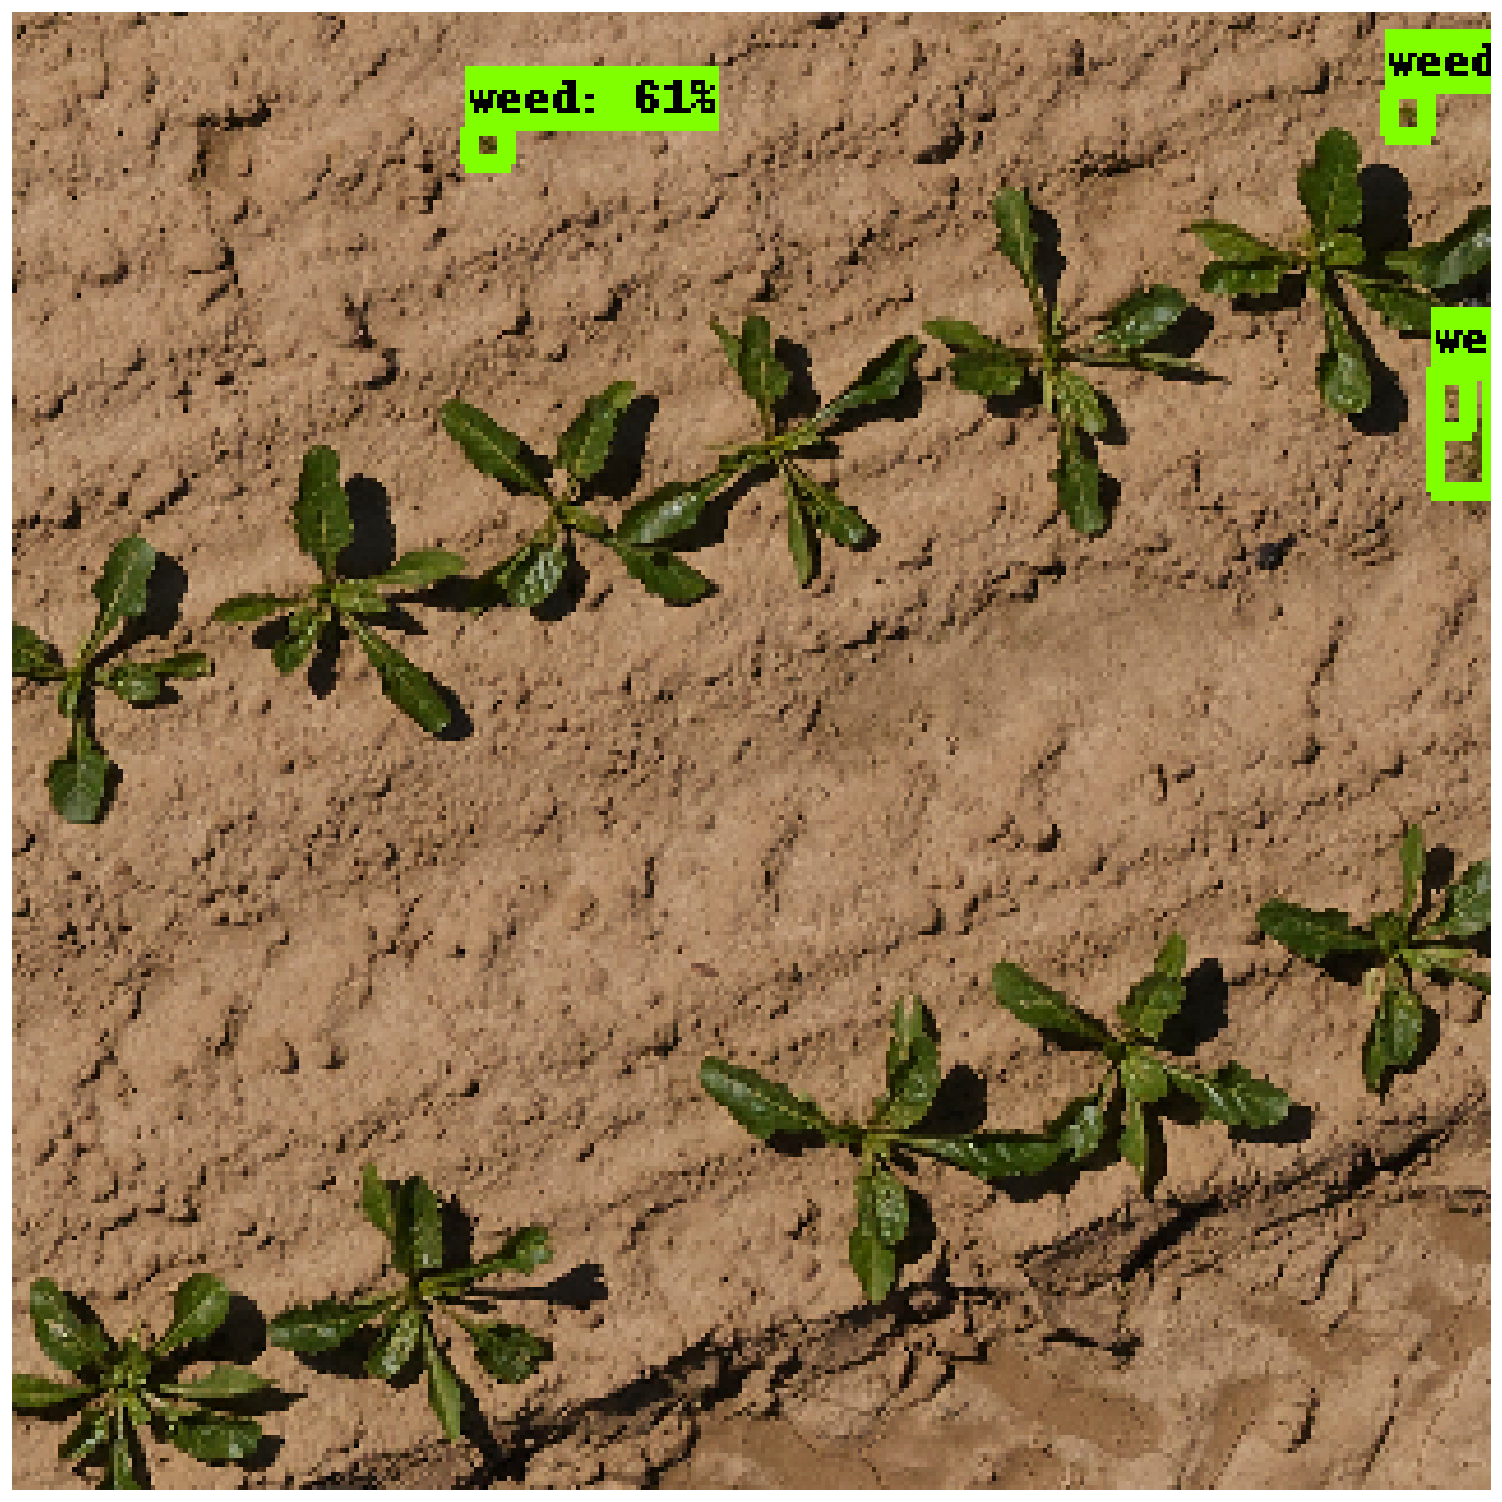

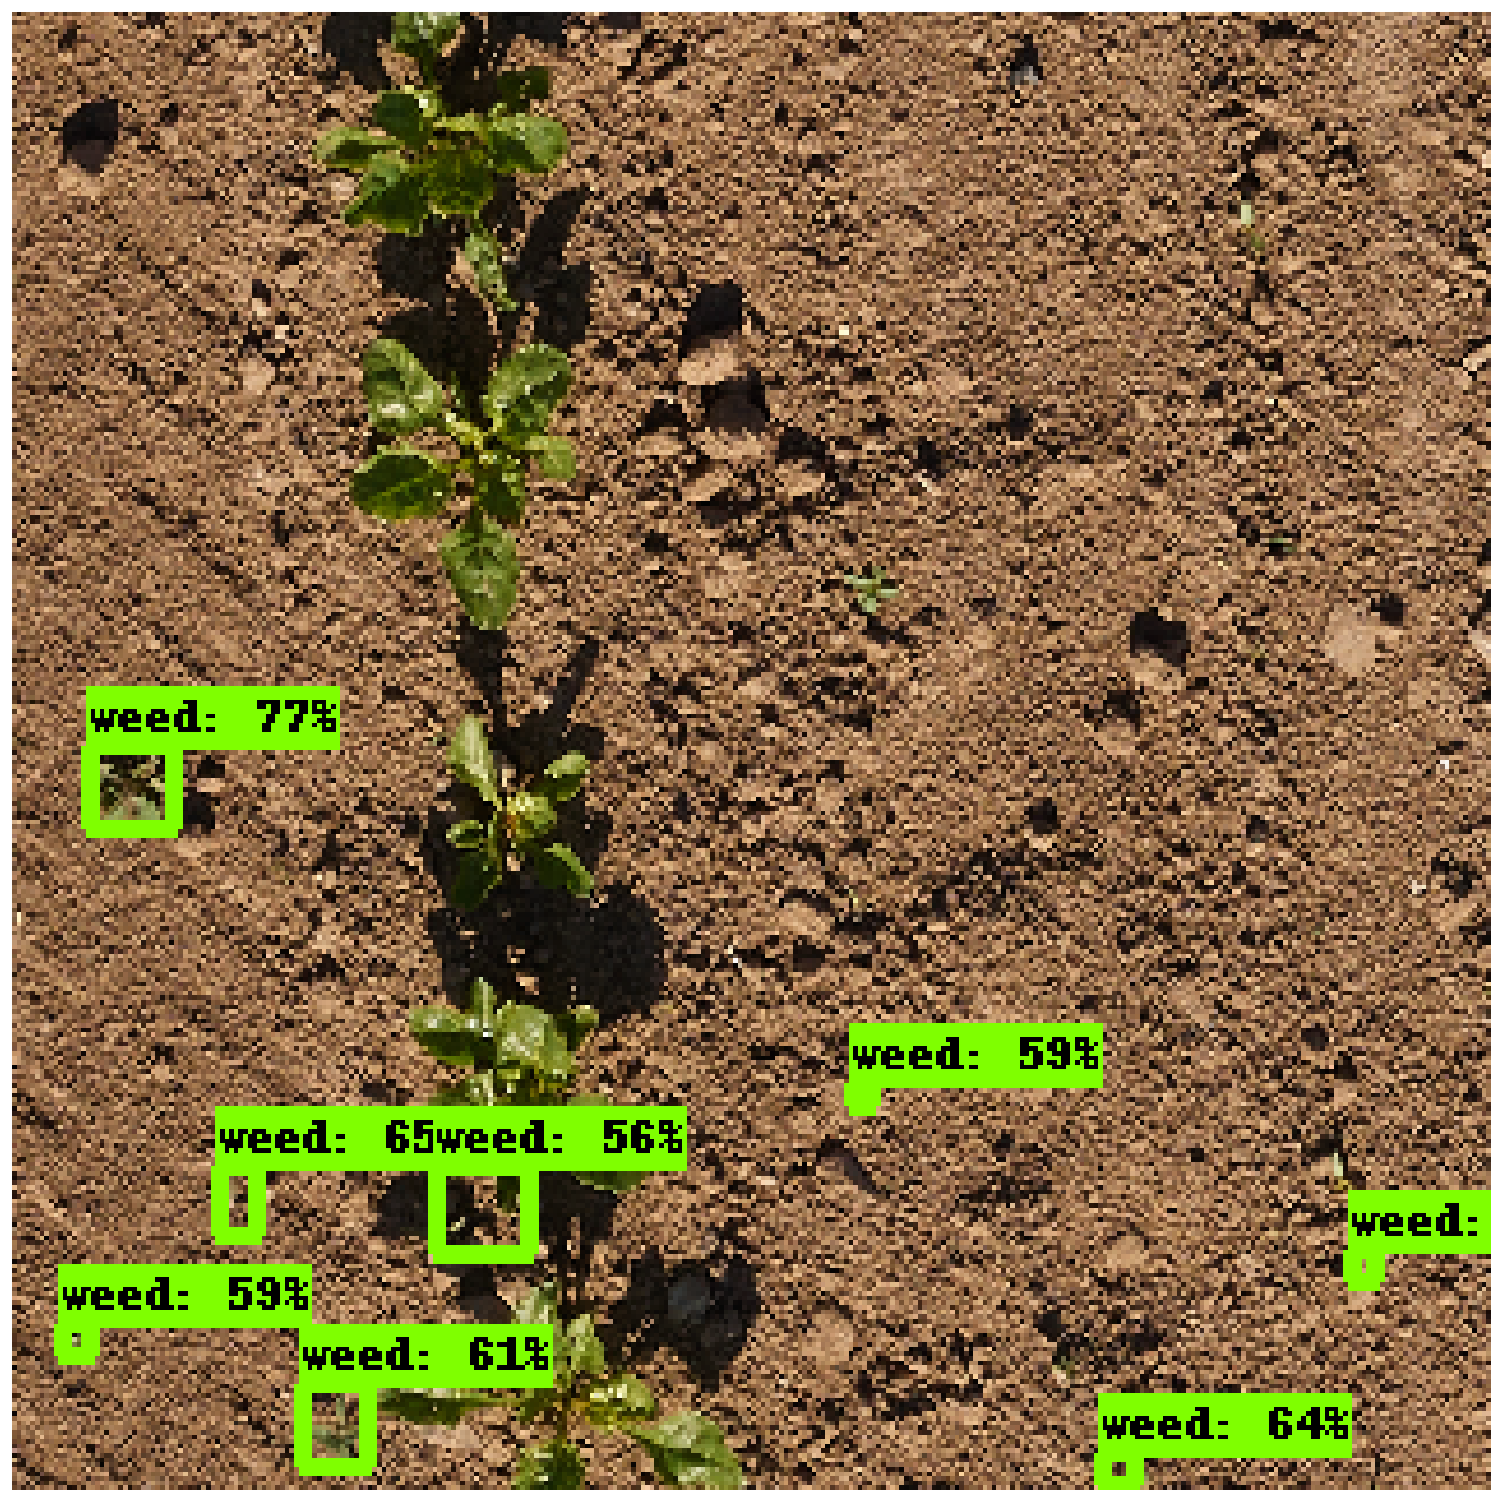

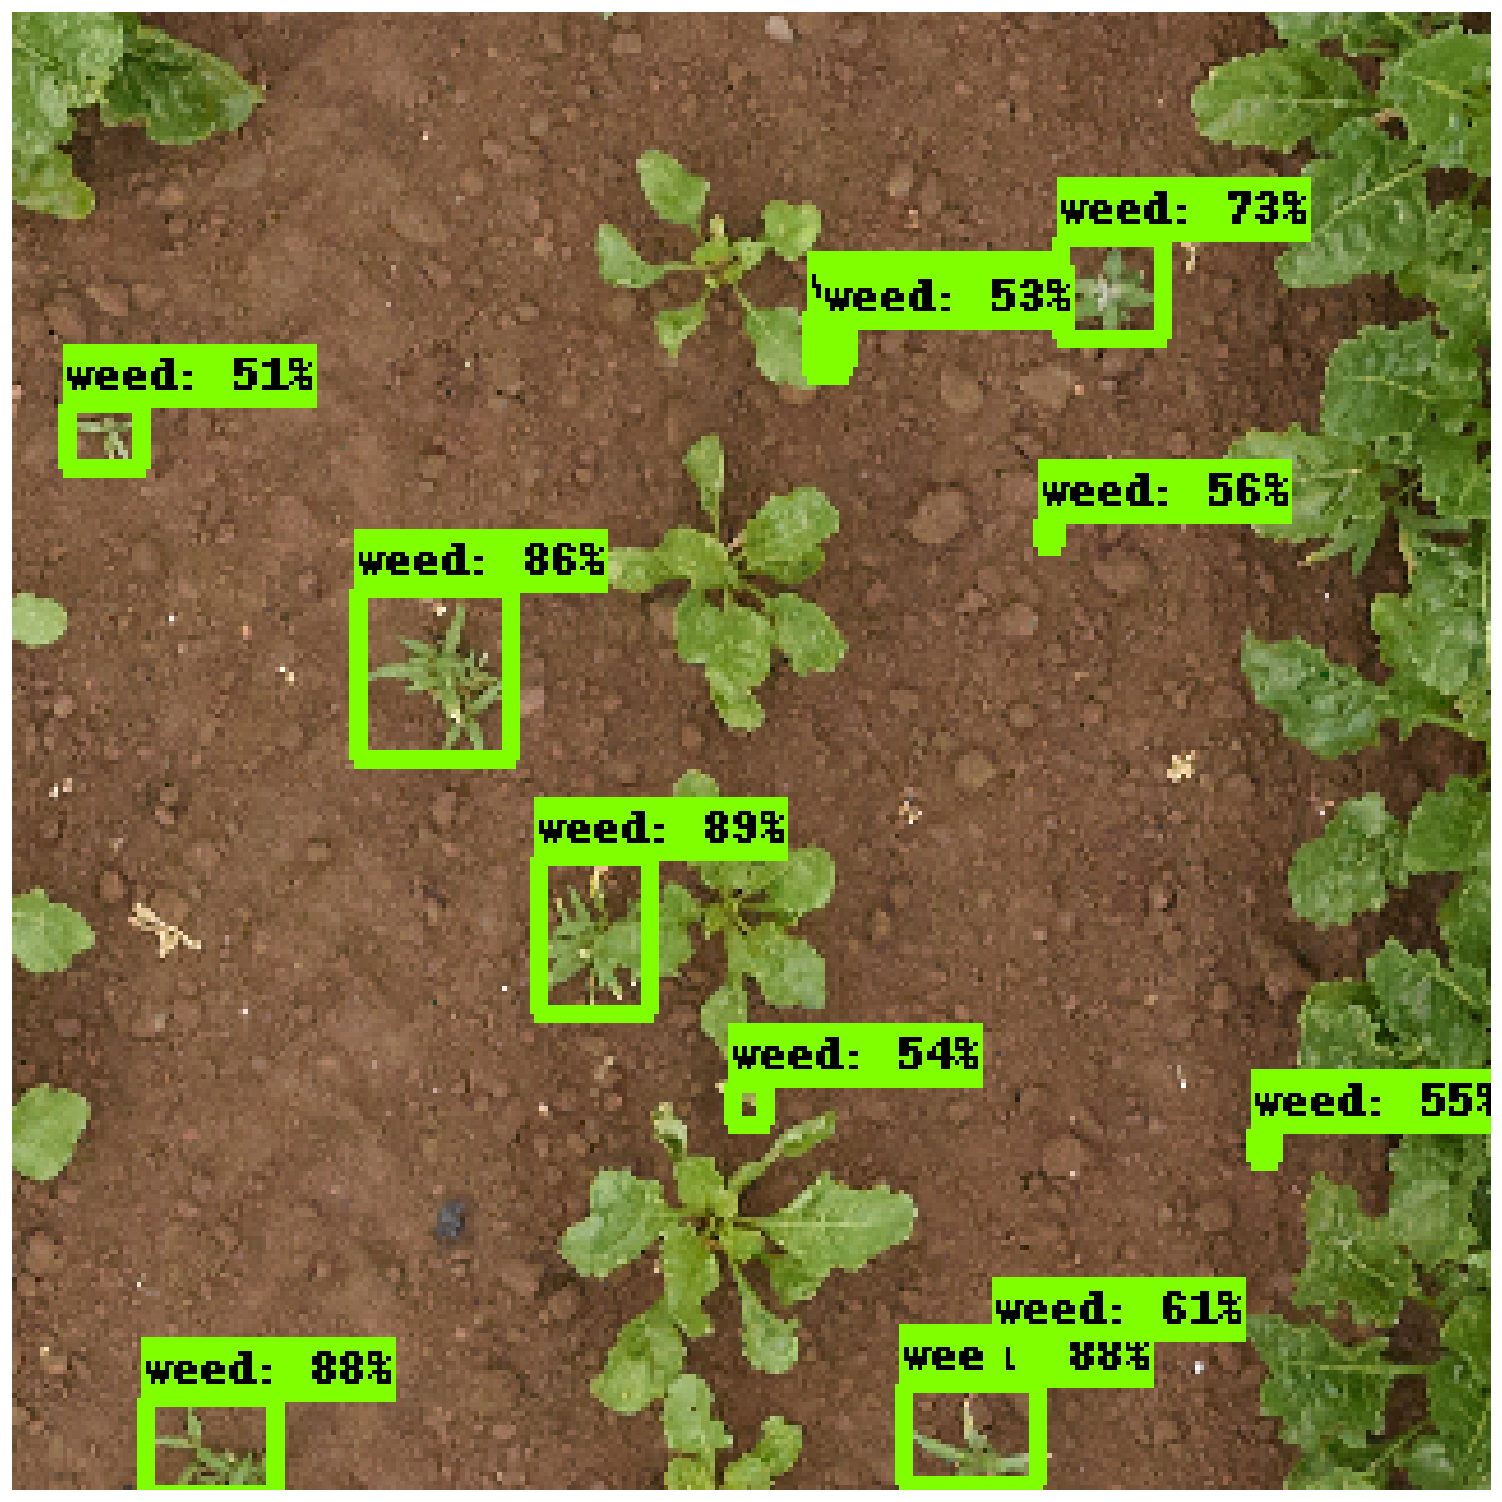

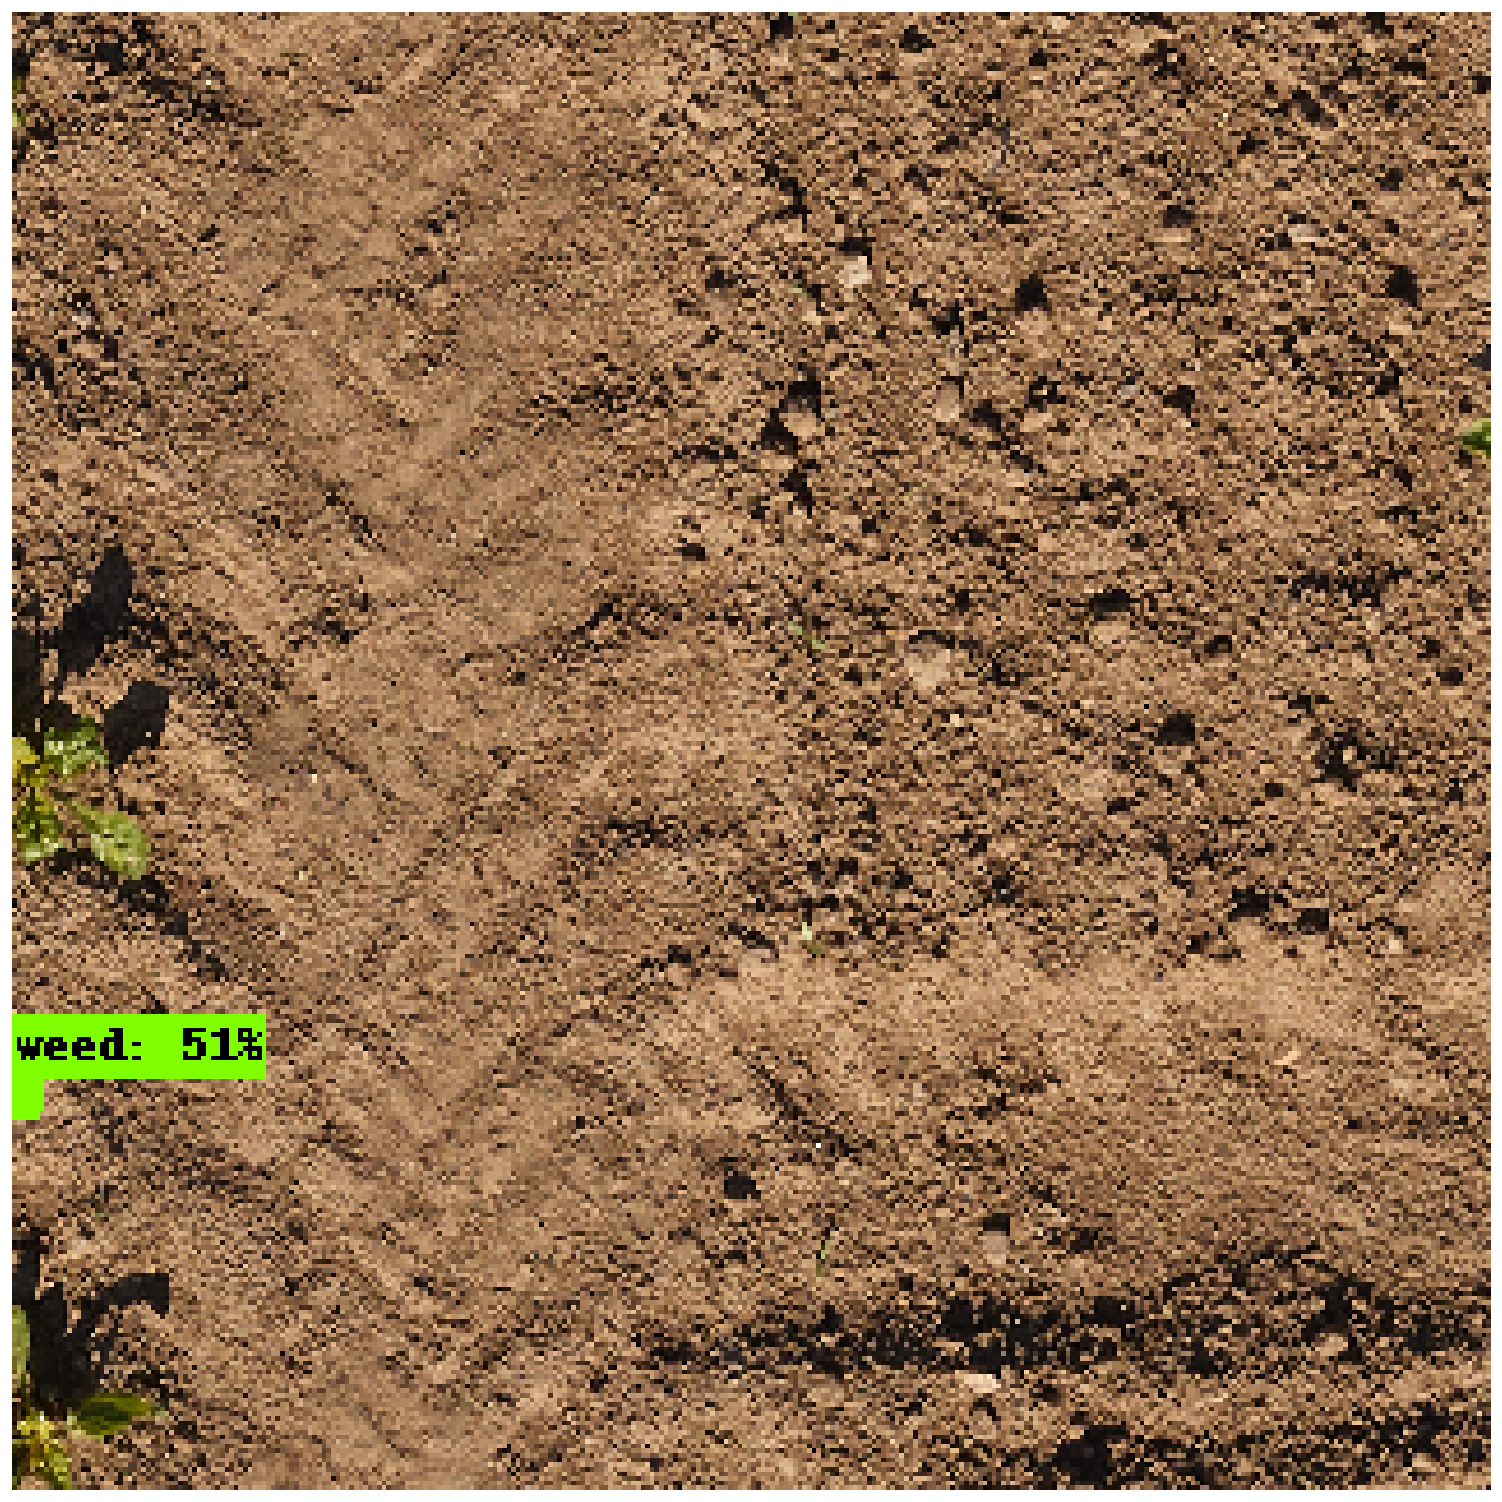

In [22]:
%matplotlib inline

from agri_vision_edge.tfod.inference import (
    load_saved_model,
    load_label_map,
    detect_image,
)

detect_fn = load_saved_model(str(QAT_DIR / "saved_model"))
category_index = load_label_map(label_map_path)

for image_path in test_imgs[:10]:
    vis, _ = detect_image(
        detect_fn=detect_fn,
        image_path=image_path,
        category_index=category_index,
        image_size=config.image_size,
        score_threshold=0.5,
        max_boxes=60,
    )
    plt.figure(figsize=(16, 16))
    plt.imshow(vis)
    plt.axis("off")
    plt.show()
    plt.close()

## 12 · Discussion

`qat3` fake-quantizes the backbone + detection head with the `full` scheme. Compare its validation
mAP against the finetune (`ptq`) and the sibling QAT schemes once all four are
merged.

Next step — **INT8 TFLite conversion:** `notebooks/tflite_conversion.py`
reconstructs this `qat3/` checkpoint (mirroring the fold + quantize graph
above) and emits the deployable int8 model.